📊 Statistische Analyse des Energieverbrauchs

**Ziel:** Verteilung, Zusammenhänge, Unterschiede und Ausreißer des Energieverbrauchs untersuchen.

In [1]:
####### 1- imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
##### 2- connexion MySQL
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="Dian-Data",
    password="dian_data_2026",
    database="ashrae_energy"
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


Phase 2 : Da train_full mehr als 20 Millionen Zeilen enthält, werden wir nicht die gesamte Tabelle in Python laden.

Für den Anfang verwenden wir eine zufällige Stichprobe von 100.000 Beobachtungen:

In [16]:
# =================================================================
# Datenbasis für die Statistik
# Zweck: Einheitliche Datenbasis mit 500.000 Strommessungen
# =================================================================

query_stat = """

SELECT
    air_temperature,
    square_feet,
    meter_reading
FROM train_full
WHERE meter = 0
  AND air_temperature IS NOT NULL
  AND square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
ORDER BY building_id, timestamp
LIMIT 500000;
"""

df_stat = pd.read_sql(query_stat, connection)

print("Anzahl Beobachtungen:", len(df_stat))
print("Anzahl der Spalten:", len(df_stat.columns))

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_30284\1687696300.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stat = pd.read_sql(query_stat, connection)


Anzahl Beobachtungen: 500000
Anzahl der Spalten: 3


In [33]:
stat_building = (
    df_stat
    .groupby("primary_use")["meter_reading"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .sort_values("Mittelwert", ascending=False)
)

display(stat_building)

,Anzahl,Mittelwert,Median,Standardabweichung,Q1,Q3
primary_use,,,,,,
Entertainment/public assembly,17206,579.837776,238.2140,727.200088,0.0,1265.1300
Education,188212,370.488423,187.0220,496.108473,0.0,514.9920
Other,24933,305.607851,48.4618,511.906690,0.0,126.8200
Lodging/residential,101130,153.262427,140.0610,158.299420,0.0,260.0550
Office,115835,141.992834,100.0630,158.192169,0.0,230.9765
Retail,43903,72.342208,4.8462,156.232150,0.0,48.7348
Parking,8781,56.583939,56.6525,51.169847,0.0,121.1540


In [9]:
df_stat["meter_reading"].describe()

count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64

In [ ]:
# Utiliser exactement la même base pour die Statistik
##df_stat = df.copy()

In [ ]:
#%pip install seaborn

In [18]:
# =================================================================
# Phase 30 – Verteilung und Streuung
# Zweck: Statistische Kennwerte des Energieverbrauchs berechnen
# =================================================================

# Deskriptive Statistik
statistiken = df_stat["meter_reading"].describe()

print("Statistische Beschreibung des Stromverbrauchs")
print("---------------------------------------------")
print(statistiken)

# Zusätzliche Kennwerte
mittelwert = df_stat["meter_reading"].mean()
median = df_stat["meter_reading"].median()
standardabweichung = df_stat["meter_reading"].std()

print("\nZusätzliche Kennwerte")
print("---------------------")
print(f"Mittelwert: {mittelwert:.2f}")
print(f"Median: {median:.2f}")
print(f"Standardabweichung: {standardabweichung:.2f}")

Statistische Beschreibung des Stromverbrauchs
---------------------------------------------
count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64

Zusätzliche Kennwerte
---------------------
Mittelwert: 245.89
Median: 83.14
Standardabweichung: 392.85


In [19]:


df_stat["meter_reading"].value_counts()

meter_reading
0.0000      191649
3.1398         613
4.7779         460
4.7438         335
3.1056         303
             ...  
381.1420         1
264.0000         1
364.0000         1
698.0000         1
650.0000         1
Name: count, Length: 48501, dtype: int64

Phase 31 – Korrelationen
Anzahl der Beobachtungen: n = 500,000

--- Pearson-Korrelation ---
Pearson r = 0.227
p-Wert    = 0

--- Spearman-Korrelation ---
Spearman ρ = 0.391
p-Wert     = 0

--- Interpretation ---
Pearson: statistisch signifikanter linearer Zusammenhang (p < 0.05).
Spearman: statistisch signifikanter monotoner Zusammenhang (p < 0.05).

Hinweis: Eine statistisch signifikante Korrelation bedeutet
keine Kausalität zwischen Temperatur und Verbrauch.


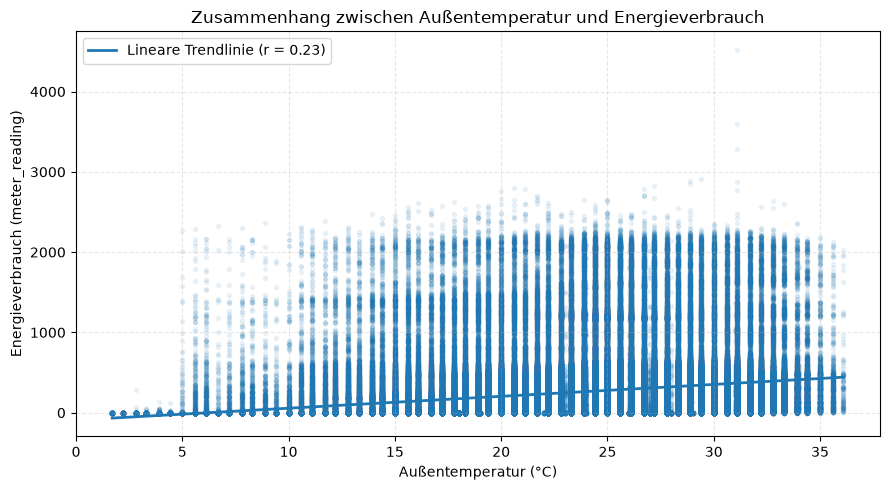

In [35]:
# =================================================================
# Phase 31 – Korrelationen
# Zweck: Zusammenhang zwischen Temperatur und Verbrauch quantifizieren
# =================================================================

from scipy.stats import pearsonr, spearmanr
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 31.1 Vorbereitung der Daten
# -----------------------------------------------------------------

df_corr = df_stat[["air_temperature", "meter_reading"]].dropna()

n_corr = len(df_corr)

print("=" * 65)
print("Phase 31 – Korrelationen")
print("=" * 65)
print(f"Anzahl der Beobachtungen: n = {n_corr:,}")


# -----------------------------------------------------------------
# 31.2 Pearson-Korrelation
# Pearson: misst den linearen Zusammenhang
# -----------------------------------------------------------------

r_pearson, p_pearson = pearsonr(
    df_corr["air_temperature"],
    df_corr["meter_reading"]
)

print("\n--- Pearson-Korrelation ---")
print(f"Pearson r = {r_pearson:.3f}")
print(f"p-Wert    = {p_pearson:.4g}")


# -----------------------------------------------------------------
# 31.3 Spearman-Korrelation
# Spearman: misst einen monotonen Zusammenhang
# -----------------------------------------------------------------

r_spearman, p_spearman = spearmanr(
    df_corr["air_temperature"],
    df_corr["meter_reading"]
)

print("\n--- Spearman-Korrelation ---")
print(f"Spearman ρ = {r_spearman:.3f}")
print(f"p-Wert     = {p_spearman:.4g}")


# -----------------------------------------------------------------
# 31.4 Statistische Interpretation
# Signifikanzniveau: α = 0.05
# -----------------------------------------------------------------

alpha = 0.05

print("\n--- Interpretation ---")

if p_pearson < alpha:
    print("Pearson: statistisch signifikanter linearer Zusammenhang (p < 0.05).")
else:
    print("Pearson: kein statistisch signifikanter linearer Zusammenhang (p ≥ 0.05).")

if p_spearman < alpha:
    print("Spearman: statistisch signifikanter monotoner Zusammenhang (p < 0.05).")
else:
    print("Spearman: kein statistisch signifikanter monotoner Zusammenhang (p ≥ 0.05).")

print("\nHinweis: Eine statistisch signifikante Korrelation bedeutet")
print("keine Kausalität zwischen Temperatur und Verbrauch.")


# =================================================================
# 31.5 Visualisierung der Korrelation
# Zweck: Grafische Darstellung des Zusammenhangs
#        zwischen Außentemperatur und Energieverbrauch
# =================================================================

# Lineare Trendlinie
z = np.polyfit(
    df_corr["air_temperature"],
    df_corr["meter_reading"],
    1
)

trend = np.poly1d(z)

x_trend = np.linspace(
    df_corr["air_temperature"].min(),
    df_corr["air_temperature"].max(),
    100
)

plt.figure(figsize=(9, 5))

plt.scatter(
    df_corr["air_temperature"],
    df_corr["meter_reading"],
    alpha=0.08,
    s=8
)

plt.plot(
    x_trend,
    trend(x_trend),
    linewidth=2,
    label=f"Lineare Trendlinie (r = {r_pearson:.2f})"
)

plt.title("Zusammenhang zwischen Außentemperatur und Energieverbrauch")
plt.xlabel("Außentemperatur (°C)")
plt.ylabel("Energieverbrauch (meter_reading)")

plt.legend()
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Phase 32 – Unterschiede zwischen Gebäuden
Anzahl Beobachtungen: 500,000
Anzahl Gebäude:       59
Anzahl Gebäudenutzungen: 7

Anzahl Gebäude pro Gebäudenutzung:
primary_use
Education                        22
Entertainment/public assembly     2
Lodging/residential              12
Office                           14
Other                             3
Parking                           1
Retail                            5
Name: count, dtype: int64

--- Deskriptive Statistik nach Gebäudenutzung ---
                               Anzahl_Gebäude  Mittelwert  Median  \
primary_use                                                         
Entertainment/public assembly               2      571.36  571.36   
Education                                  22      384.61  289.85   
Other                                       3      293.04   70.87   
Lodging/residential                        12      150.27  144.13   
Office                                     14      136.58  127.22   
Retail          

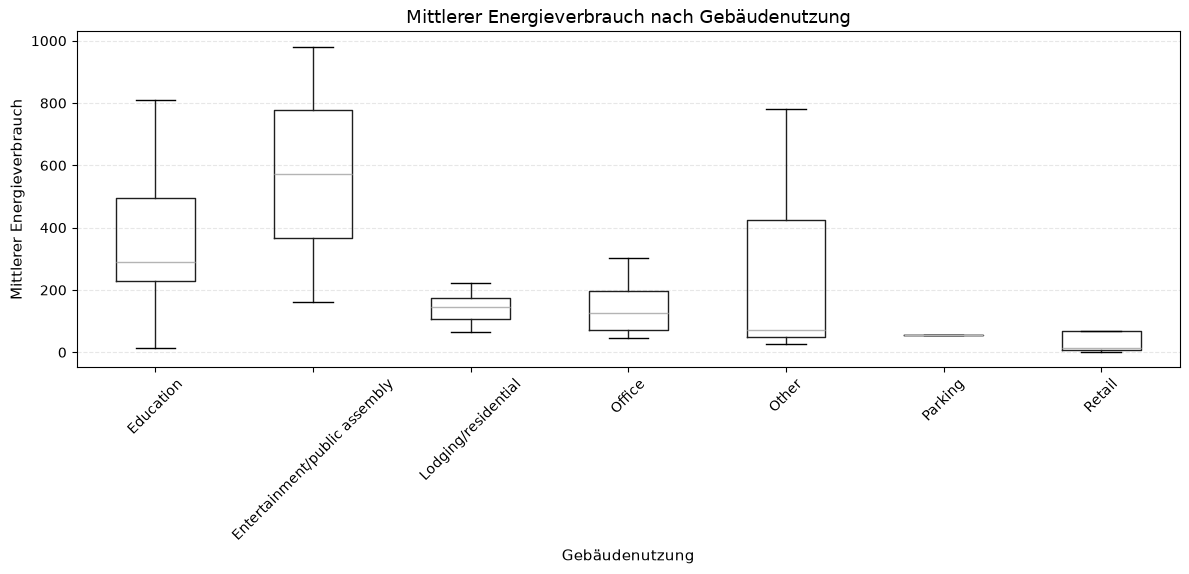

In [40]:
# =================================================================
# Phase 32 – Unterschiede zwischen Gebäuden
# Zweck: Statistischer Vergleich des Verbrauchs nach Gebäudenutzung
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# -----------------------------------------------------------------
# 32.1 Vorbereitung der Daten
# -----------------------------------------------------------------

df_anova = df_stat[["building_id", "primary_use", "meter_reading"]].dropna()

print("=" * 65)
print("Phase 32 – Unterschiede zwischen Gebäuden")
print("=" * 65)

print(f"Anzahl Beobachtungen: {len(df_anova):,}")
print(f"Anzahl Gebäude:       {df_anova['building_id'].nunique():,}")
print(f"Anzahl Gebäudenutzungen: {df_anova['primary_use'].nunique()}")


# -----------------------------------------------------------------
# 32.2 Verbrauch pro Gebäude zusammenfassen
# -----------------------------------------------------------------
# Jeder Gebäude wird zunächst ein mittlerer Verbrauch zugeordnet.
# Dadurch werden Gebäude mit sehr vielen Messungen nicht
# automatisch stärker gewichtet.

df_building = (
    df_anova
    .groupby(["building_id", "primary_use"], as_index=False)
    ["meter_reading"]
    .mean()
    .rename(columns={"meter_reading": "mean_consumption"})
)

print("\nAnzahl Gebäude pro Gebäudenutzung:")
print(
    df_building["primary_use"]
    .value_counts()
    .sort_index()
)


# -----------------------------------------------------------------
# 32.3 Deskriptiver Vergleich
# -----------------------------------------------------------------

summary_building = (
    df_building
    .groupby("primary_use")["mean_consumption"]
    .agg(
        Anzahl_Gebäude="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std"
    )
    .sort_values("Mittelwert", ascending=False)
)

print("\n--- Deskriptive Statistik nach Gebäudenutzung ---")
print(summary_building.round(2))


# -----------------------------------------------------------------
# 32.4 Gruppen für ANOVA vorbereiten
# -----------------------------------------------------------------

gruppen = [
    gruppe["mean_consumption"].values
    for _, gruppe in df_building.groupby("primary_use")
    if len(gruppe) >= 2
]

gruppen_namen = [
    name
    for name, gruppe in df_building.groupby("primary_use")
    if len(gruppe) >= 2
]

print("\nFür die ANOVA verwendete Gruppen:")
print(gruppen_namen)


# -----------------------------------------------------------------
# 32.5 One-Way-ANOVA
# -----------------------------------------------------------------

f_stat, p_value = stats.f_oneway(*gruppen)

print("\n--- One-Way-ANOVA ---")
print(f"F-Statistik = {f_stat:.3f}")
print(f"p-Wert      = {p_value:.4g}")

alpha = 0.05

if p_value < alpha:
    print(
        "→ Statistisch signifikanter Unterschied "
        "zwischen mindestens zwei Gebäudenutzungen (p < 0.05)."
    )
else:
    print(
        "→ Kein statistisch signifikanter Unterschied "
        "zwischen den Gebäudenutzungen (p ≥ 0.05)."
    )


# -----------------------------------------------------------------
# 32.6 Post-hoc-Test bei signifikanter ANOVA
# -----------------------------------------------------------------
# Nur durchführen, wenn die ANOVA signifikant ist.

if p_value < alpha:

    tukey = pairwise_tukeyhsd(
        endog=df_building["mean_consumption"],
        groups=df_building["primary_use"],
        alpha=alpha
    )

    print("\n--- Tukey Post-hoc-Test ---")
    print(tukey)


# =================================================================
# 32.7 Visualisierung
# =================================================================
fig, ax = plt.subplots(figsize=(12, 6))

df_building.boxplot(
    column="mean_consumption",
    by="primary_use",
    grid=False,
    showfliers=False,
    ax=ax
)

ax.set_title("Mittlerer Energieverbrauch nach Gebäudenutzung", fontsize=13)
ax.set_xlabel("Gebäudenutzung", fontsize=11)
ax.set_ylabel("Mittlerer Energieverbrauch", fontsize=11)
plt.suptitle("")

ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Phase 33 – Ausreißer und Extremwerte
Anzahl gültiger Werte:       500,000

--- IQR-Methode ---
Q1 (25. Perzentil):          0.00
Q3 (75. Perzentil):          331.38
IQR:                         331.38

Untere Grenze:               -497.07
Obere Grenze:                828.46

--- Ausreißer ---
Anzahl Ausreißer insgesamt:  36,833
Anteil an den Daten:         7.37%

Anzahl hoher Ausreißer:       36,833

--- Interpretation ---
→ Nach der IQR-Methode wurden statistisch auffällige Verbrauchswerte identifiziert.
→ Diese Werte werden nicht automatisch als Fehler betrachtet.


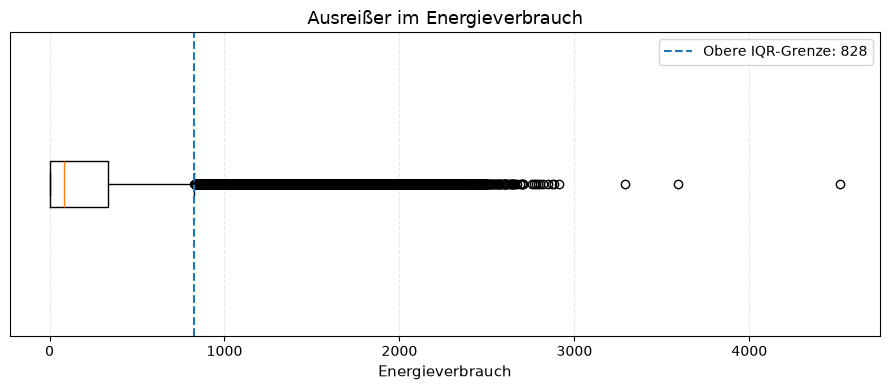

In [41]:
# =================================================================
# Phase 33 – Ausreißer und Extremwerte
# Zweck: Identifikation und Einordnung auffälliger Verbrauchswerte
# =================================================================

import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 33.1 Vorbereitung der Daten
# -----------------------------------------------------------------

df_outlier = df_stat["meter_reading"].dropna()

# -----------------------------------------------------------------
# 33.2 Berechnung der IQR-Grenzen
# -----------------------------------------------------------------

Q1 = df_outlier.quantile(0.25)
Q3 = df_outlier.quantile(0.75)

IQR = Q3 - Q1

# Untere und obere Grenze der IQR-Methode
untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

# Ausreißer identifizieren
outliers = df_outlier[
    (df_outlier < untere_grenze) |
    (df_outlier > obere_grenze)
]

# Nur hohe Verbrauchswerte
hohe_ausreisser = df_outlier[
    df_outlier > obere_grenze
]

# -----------------------------------------------------------------
# 33.3 Ergebnisse
# -----------------------------------------------------------------

print("=" * 65)
print("Phase 33 – Ausreißer und Extremwerte")
print("=" * 65)

print(f"Anzahl gültiger Werte:       {len(df_outlier):,}")

print("\n--- IQR-Methode ---")
print(f"Q1 (25. Perzentil):          {Q1:.2f}")
print(f"Q3 (75. Perzentil):          {Q3:.2f}")
print(f"IQR:                         {IQR:.2f}")

print(f"\nUntere Grenze:               {untere_grenze:.2f}")
print(f"Obere Grenze:                {obere_grenze:.2f}")

print("\n--- Ausreißer ---")
print(f"Anzahl Ausreißer insgesamt:  {len(outliers):,}")
print(
    f"Anteil an den Daten:         "
    f"{len(outliers) / len(df_outlier) * 100:.2f}%"
)

print(f"\nAnzahl hoher Ausreißer:       {len(hohe_ausreisser):,}")

# -----------------------------------------------------------------
# 33.4 Interpretation
# -----------------------------------------------------------------

print("\n--- Interpretation ---")

if len(outliers) > 0:
    print(
        "→ Nach der IQR-Methode wurden statistisch auffällige "
        "Verbrauchswerte identifiziert."
    )
    print(
        "→ Diese Werte werden nicht automatisch als Fehler betrachtet."
    )
else:
    print(
        "→ Nach der IQR-Methode wurden keine statistisch "
        "auffälligen Verbrauchswerte identifiziert."
    )


# =================================================================
# 33.5 Visualisierung
# =================================================================

plt.figure(figsize=(9, 4))

plt.boxplot(
    df_outlier,
    orientation="horizontal",
    showfliers=True
)

plt.axvline(
    obere_grenze,
    linestyle="--",
    linewidth=1.5,
    label=f"Obere IQR-Grenze: {obere_grenze:.0f}"
)

plt.title(
    "Ausreißer im Energieverbrauch",
    fontsize=13
)

plt.xlabel(
    "Energieverbrauch",
    fontsize=11
)

plt.yticks([])

plt.legend()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [42]:
mittelwert = df_stat["meter_reading"].mean()
median = df_stat["meter_reading"].median()
std = df_stat["meter_reading"].std()

print(f"Mittelwert: {mittelwert:.2f}")
print(f"Median:     {median:.2f}")
print(f"Std.-Abw.:  {std:.2f}")

Mittelwert: 245.89
Median:     83.14
Std.-Abw.:  392.85


In [43]:
# =================================================================
# Phase 34 – Statistische Interpretation
# Zweck: Zusammenfassung der Ergebnisse und Beantwortung der
#       zentralen Fragestellung
# =================================================================

print("=" * 65)
print("Phase 34 – Statistische Interpretation")
print("=" * 65)


# -----------------------------------------------------------------
# 34.1 Deskriptive Statistik
# -----------------------------------------------------------------

print("\n--- 1. Verteilung des Energieverbrauchs ---")

print(f"Mittelwert:           {mittelwert:.2f}")
print(f"Median:               {median:.2f}")
print(f"Standardabweichung:   {std:.2f}")


# -----------------------------------------------------------------
# 34.2 Zusammenhang zwischen Temperatur und Verbrauch
# -----------------------------------------------------------------

print("\n--- 2. Temperatur und Energieverbrauch ---")

print(
    f"Pearson-Korrelation: r = {r_pearson:.3f}, "
    f"p = {p_pearson:.4g}"
)

if p_pearson < 0.05:

    if r_pearson > 0:
        print(
            "→ Es besteht ein statistisch signifikanter "
            "positiver Zusammenhang zwischen Temperatur "
            "und Energieverbrauch."
        )

    elif r_pearson < 0:
        print(
            "→ Es besteht ein statistisch signifikanter "
            "negativer Zusammenhang zwischen Temperatur "
            "und Energieverbrauch."
        )

    else:
        print(
            "→ Der Zusammenhang ist statistisch signifikant, "
            "aber die Korrelation ist praktisch sehr gering."
        )

else:

    print(
        "→ Es besteht kein statistisch signifikanter "
        "linearer Zusammenhang zwischen Temperatur "
        "und Energieverbrauch."
    )


# -----------------------------------------------------------------
# 34.3 Unterschiede zwischen Gebäudenutzungen
# -----------------------------------------------------------------

print("\n--- 3. Unterschiede zwischen Gebäudenutzungen ---")

if "f_stat" in locals() and "p_value" in locals():

    print(f"ANOVA: F = {f_stat:.3f}, p = {p_value:.4g}")

    if p_value < 0.05:

        print(
            "→ Die ANOVA zeigt einen statistisch signifikanten "
            "Unterschied zwischen mindestens zwei "
            "Gebäudenutzungen."
        )

    else:

        print(
            "→ Die ANOVA zeigt keinen statistisch signifikanten "
            "Unterschied zwischen den Gebäudenutzungen."
        )

else:

    print(
        "→ Die ANOVA konnte nicht durchgeführt werden."
    )


# -----------------------------------------------------------------
# 34.4 Ausreißer und Extremwerte
# -----------------------------------------------------------------

print("\n--- 4. Ausreißer und Extremwerte ---")

anzahl_ausreisser = len(outliers)
anteil_ausreisser = (
    anzahl_ausreisser / len(df_outlier) * 100
)

print(
    f"Anzahl der Ausreißer: {anzahl_ausreisser:,}"
)

print(
    f"Anteil der Ausreißer: {anteil_ausreisser:.2f}%"
)

if anzahl_ausreisser > 0:

    print(
        "→ Es wurden statistisch auffällige "
        "Verbrauchswerte identifiziert."
    )
    print(
        "→ Diese Werte werden nicht automatisch als Fehler "
        "interpretiert, da sie auch reale hohe Verbräuche "
        "darstellen können."
    )

else:

    print(
        "→ Es wurden keine statistisch auffälligen "
        "Verbrauchswerte identifiziert."
    )


# -----------------------------------------------------------------
# 34.5 Gesamteinschätzung
# -----------------------------------------------------------------

print("\n--- 5. Gesamteinschätzung ---")

print(
    "Die statistische Analyse zeigt, dass der Energieverbrauch "
    "zwischen einzelnen Gebäuden und Gebäudenutzungen variieren kann."
)

print(
    "Zusätzlich wurde untersucht, ob ein statistischer Zusammenhang "
    "zwischen Außentemperatur und Energieverbrauch besteht."
)

print(
    "Die Ergebnisse der Korrelationsanalyse, der ANOVA und der "
    "Ausreißeranalyse ergänzen die zuvor durchgeführte deskriptive "
    "und explorative Analyse."
)

print(
    "\nHinweis: Statistische Zusammenhänge erlauben keine direkten "
    "Aussagen über Kausalität."
)

print("\n" + "=" * 65)
print("STATISTISCHE ANALYSE ABGESCHLOSSEN")
print("=" * 65)

Phase 34 – Statistische Interpretation

--- 1. Verteilung des Energieverbrauchs ---
Mittelwert:           245.89
Median:               83.14
Standardabweichung:   392.85

--- 2. Temperatur und Energieverbrauch ---
Pearson-Korrelation: r = 0.227, p = 0
→ Es besteht ein statistisch signifikanter positiver Zusammenhang zwischen Temperatur und Energieverbrauch.

--- 3. Unterschiede zwischen Gebäudenutzungen ---
ANOVA: F = 3.500, p = 0.008407
→ Die ANOVA zeigt einen statistisch signifikanten Unterschied zwischen mindestens zwei Gebäudenutzungen.

--- 4. Ausreißer und Extremwerte ---
Anzahl der Ausreißer: 36,833
Anteil der Ausreißer: 7.37%
→ Es wurden statistisch auffällige Verbrauchswerte identifiziert.
→ Diese Werte werden nicht automatisch als Fehler interpretiert, da sie auch reale hohe Verbräuche darstellen können.

--- 5. Gesamteinschätzung ---
Die statistische Analyse zeigt, dass der Energieverbrauch zwischen einzelnen Gebäuden und Gebäudenutzungen variieren kann.
Zusätzlich wurde unt

„Der Kruskal-Wallis-Test zeigt einen statistisch signifikanten Unterschied im Energieverbrauch zwischen den Gebäudetypen (H = 3027,96; p < 0,05).“

„Der Kruskal-Wallis-Test zeigt statistisch signifikante Unterschiede im Energieverbrauch zwischen den Gebäudetypen (H = 3027,96; p < 0,05). Der anschließende Dunn-Post-hoc-Test zeigt, dass sich mehrere Gebäudetypen signifikant voneinander unterscheiden. Die Effektstärke von ε² = 0,030 weist jedoch auf einen relativ kleinen bis moderaten Gesamteffekt hin.“